## 02 — Exploratory Data Analysis
Understand revenue patterns, seasonality, top products, and customer distribution
before building forecasting models.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
sns.set_style('whitegrid')

df       = pd.read_csv('../data/processed/cleaned_sales.csv', parse_dates=['InvoiceDate'])
monthly  = pd.read_csv('../data/processed/monthly_sales.csv')
monthly['InvoiceDate'] = pd.to_datetime(monthly['YearMonth'])

print(f'Loaded {len(df):,} rows  |  {monthly.shape[0]} monthly periods')

Loaded 1,003,466 rows  |  25 monthly periods


## 1. Monthly revenue trend

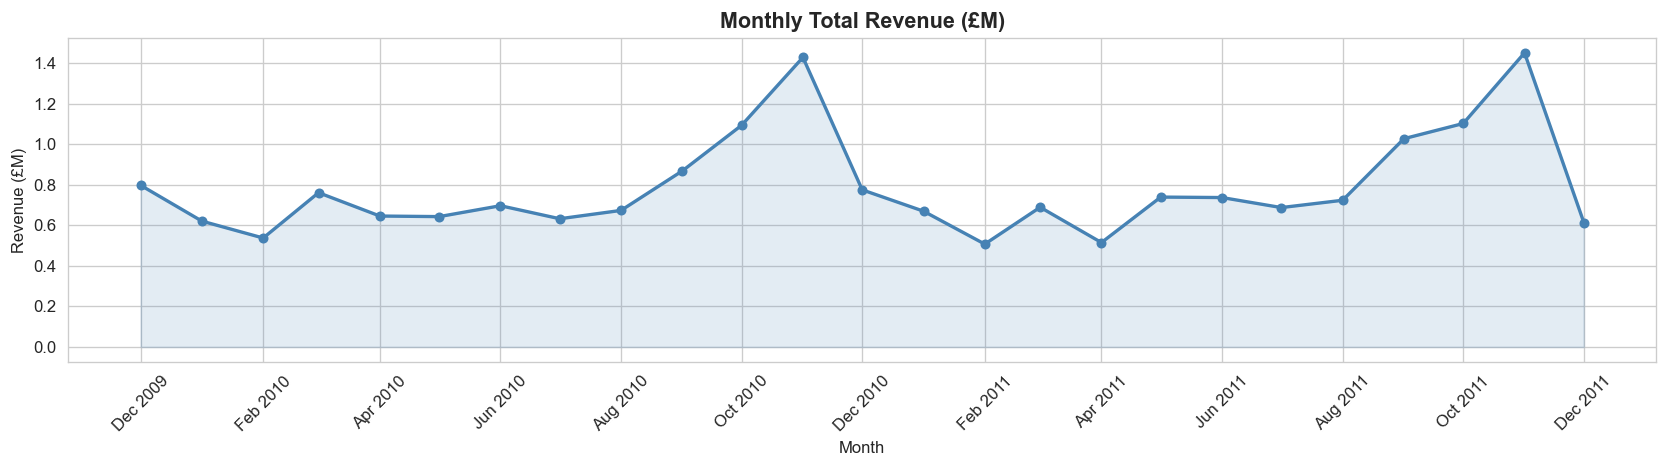

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly['InvoiceDate'], monthly['TotalRevenue'] / 1e6,
        marker='o', linewidth=2, color='steelblue', markersize=5)
ax.fill_between(monthly['InvoiceDate'], monthly['TotalRevenue'] / 1e6, alpha=0.15, color='steelblue')
ax.set_title('Monthly Total Revenue (£M)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£M)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/monthly_revenue_trend.png', bbox_inches='tight')
plt.show()

## 2. Seasonal decomposition

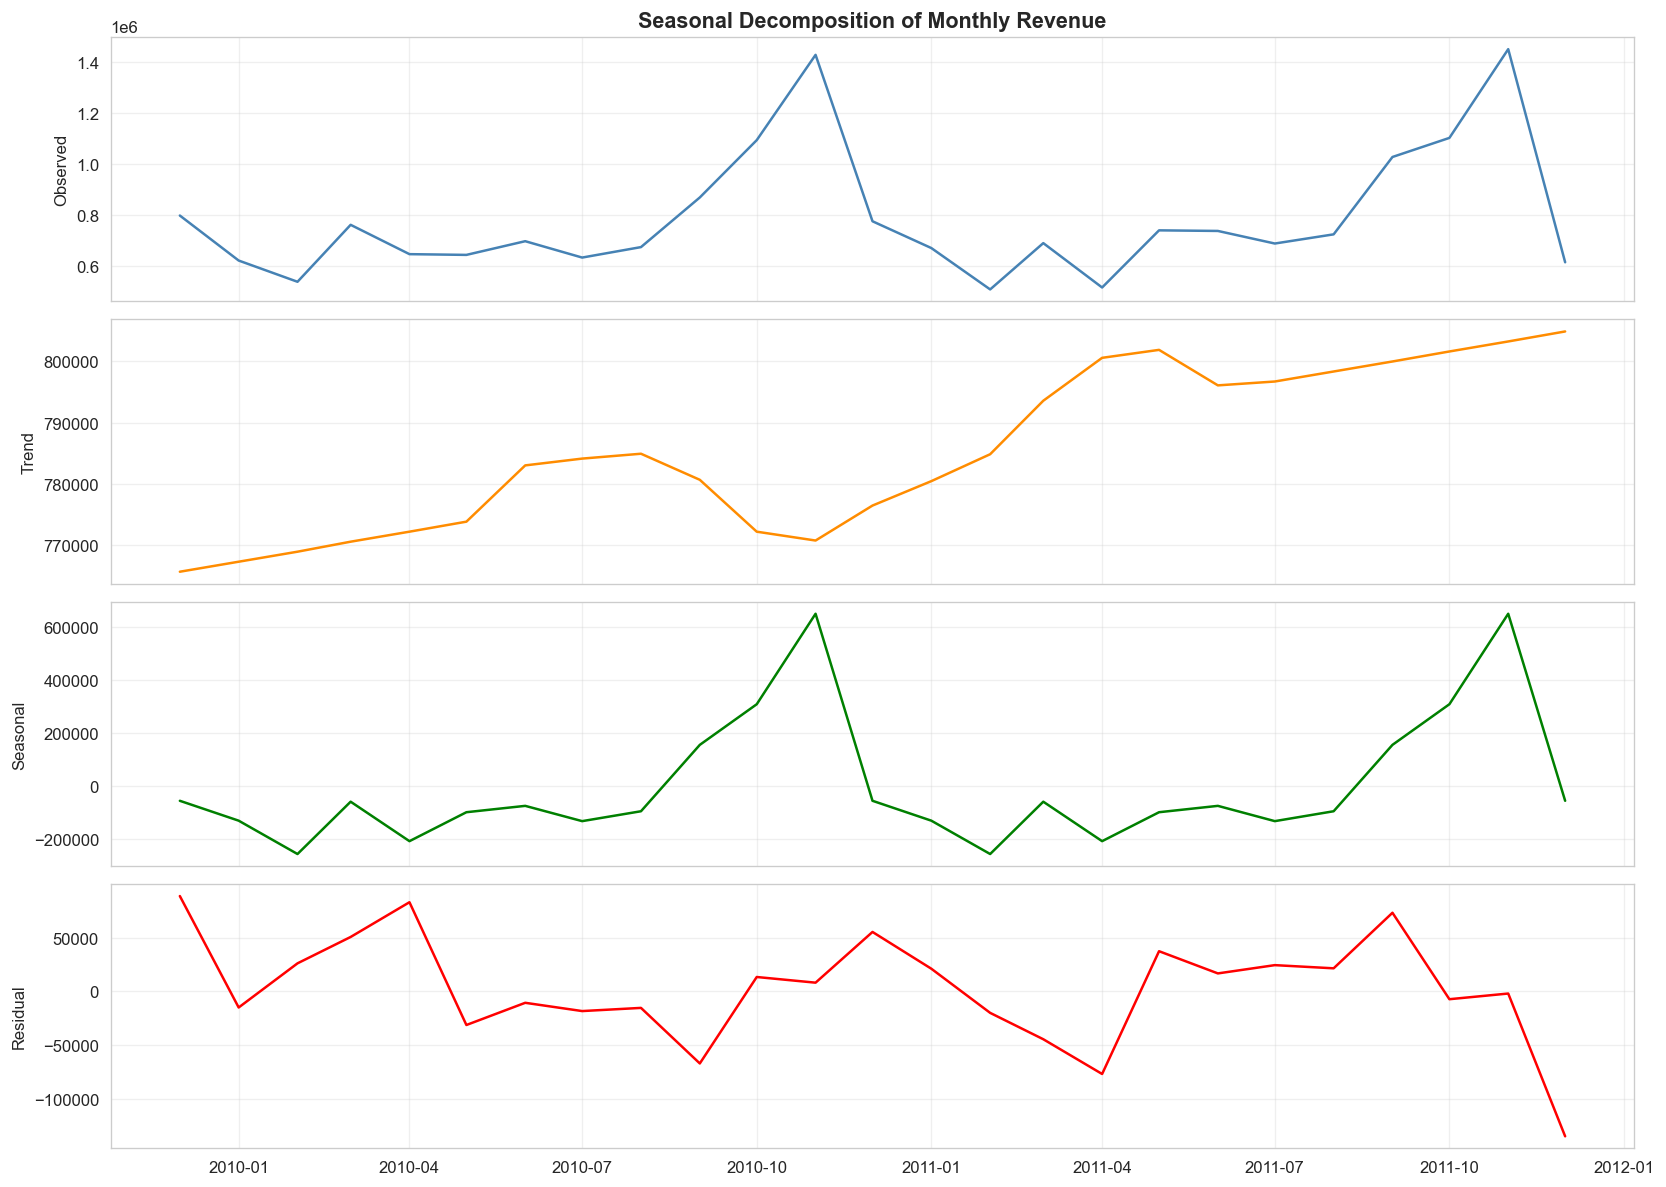

Seasonal component by month (relative to mean):
  Month 01: -£131,141  ██████████████████████████
  Month 02: -£257,150  ███████████████████████████████████████████████████
  Month 03: -£59,425  ███████████
  Month 04: -£208,561  █████████████████████████████████████████
  Month 05: -£99,186  ███████████████████
  Month 06: -£75,156  ███████████████
  Month 07: -£132,892  ██████████████████████████
  Month 08: -£95,519  ███████████████████
  Month 09: +£155,350  ███████████████████████████████
  Month 10: +£308,898  █████████████████████████████████████████████████████████████
  Month 11: +£650,789  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Month 12: -£56,005  ███████████


In [6]:
# Use the full 25-month series for decomposition
ts = monthly.set_index('InvoiceDate')['TotalRevenue'].sort_index()

# period=12 for annual seasonality (monthly data)
decomp = seasonal_decompose(ts, model='additive', period=12, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
components = [('Observed', decomp.observed), ('Trend', decomp.trend),
              ('Seasonal', decomp.seasonal), ('Residual', decomp.resid)]
colors = ['steelblue', 'darkorange', 'green', 'red']

for ax, (name, comp), color in zip(axes, components, colors):
    ax.plot(comp, color=color, linewidth=1.5)
    ax.set_ylabel(name)
    ax.grid(True, alpha=0.3)

axes[0].set_title('Seasonal Decomposition of Monthly Revenue', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/seasonal_decomposition.png', bbox_inches='tight')
plt.show()

print('Seasonal component by month (relative to mean):')
seasonal_avg = decomp.seasonal.groupby(decomp.seasonal.index.month).mean()
for m, v in seasonal_avg.items():
    bar = '█' * int(abs(v) / 5000)
    sign = '+' if v > 0 else '-'
    print(f'  Month {m:02d}: {sign}£{abs(v):,.0f}  {bar}')

## 3. ACF / PACF — choose ARIMA parameters

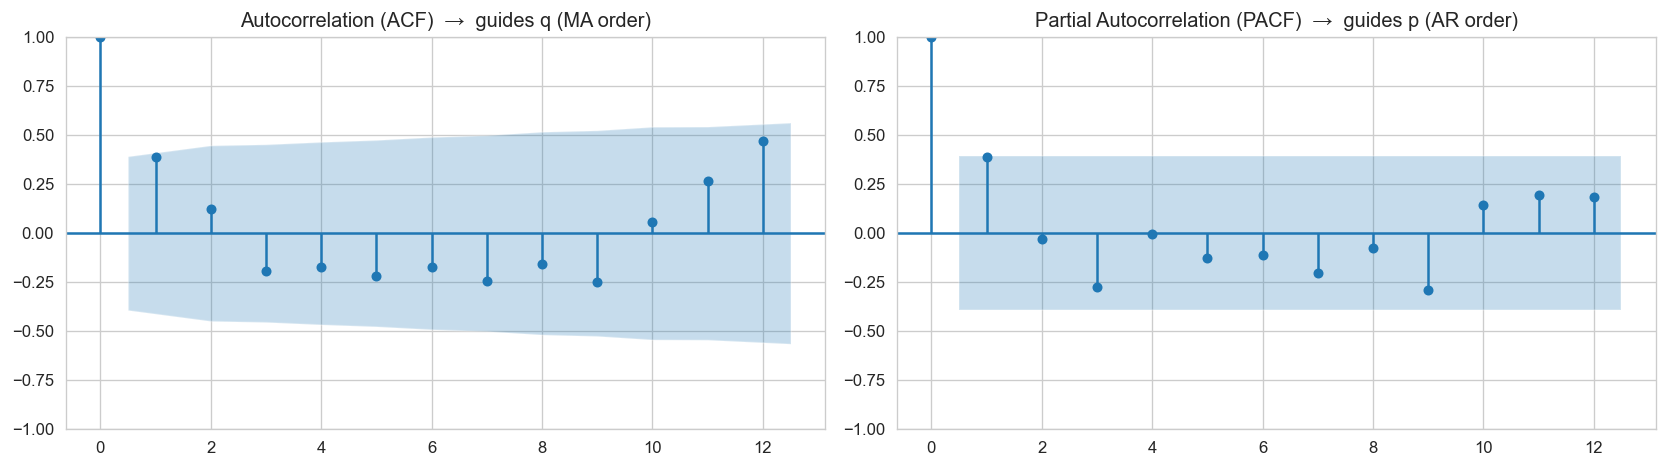

Reading guide:
  - Spikes in ACF at lag 12 → seasonal pattern (S=12)
  - ACF cuts off after lag q → MA(q)
  - PACF cuts off after lag p → AR(p)
  - Slow ACF decay → series needs differencing (d=1)


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(ts, lags=12, ax=ax1)
ax1.set_title('Autocorrelation (ACF)  →  guides q (MA order)')

plot_pacf(ts, lags=12, ax=ax2, method='ywm')
ax2.set_title('Partial Autocorrelation (PACF)  →  guides p (AR order)')

plt.tight_layout()
plt.savefig('../reports/acf_pacf.png', bbox_inches='tight')
plt.show()

print('Reading guide:')
print('  - Spikes in ACF at lag 12 → seasonal pattern (S=12)')
print('  - ACF cuts off after lag q → MA(q)')
print('  - PACF cuts off after lag p → AR(p)')
print('  - Slow ACF decay → series needs differencing (d=1)')

## 4. Revenue by day of week

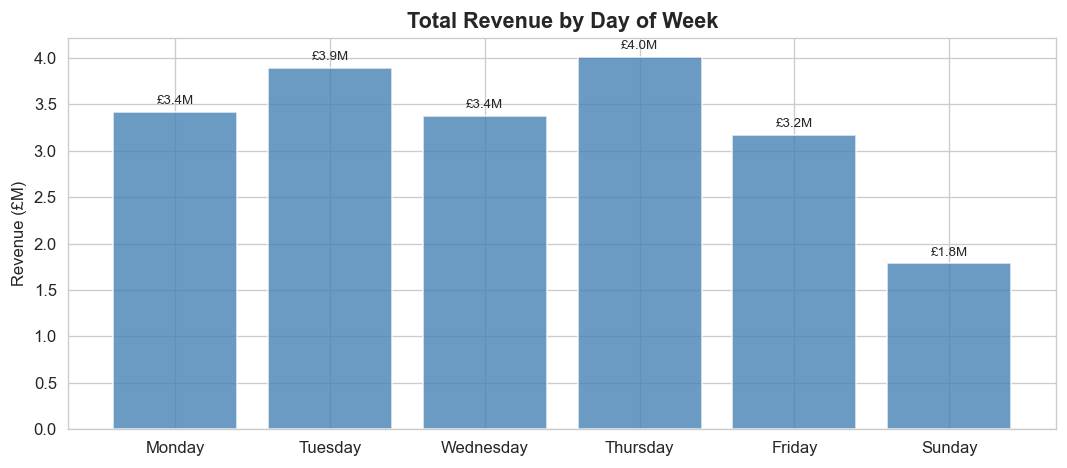

In [8]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday']
day_rev = (
    df.groupby('DayOfWeekName')['TotalRevenue']
    .sum()
    .reindex(day_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(day_rev['DayOfWeekName'], day_rev['TotalRevenue'] / 1e6, color='steelblue', alpha=0.8)
ax.set_title('Total Revenue by Day of Week', fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue (£M)')
ax.set_xlabel('')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'£{bar.get_height():.1f}M', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('../reports/revenue_by_day.png', bbox_inches='tight')
plt.show()

## 5. Revenue by hour

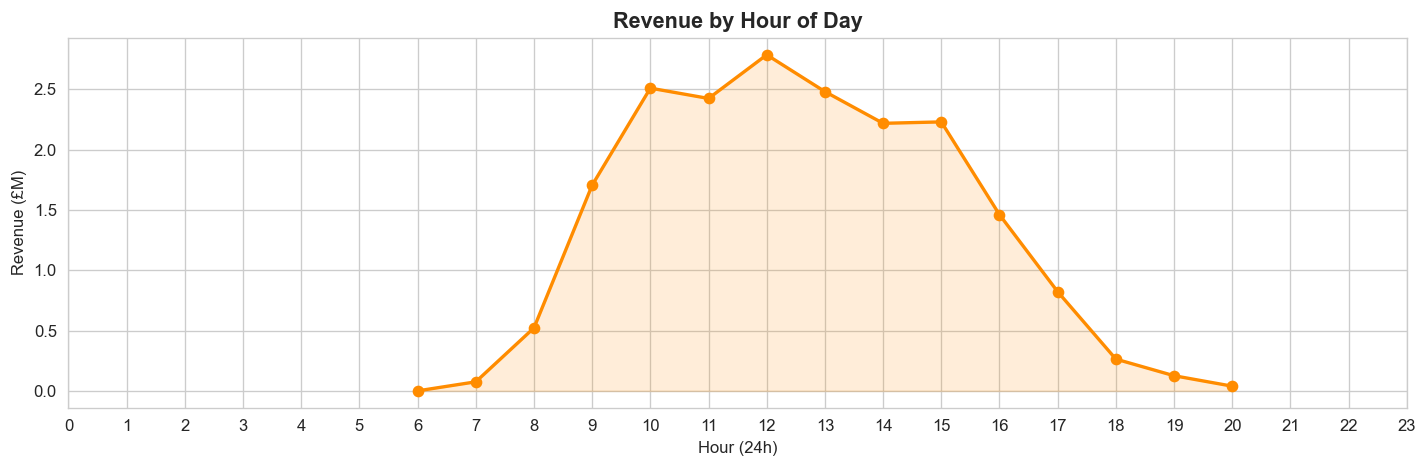

In [9]:
hour_rev = df.groupby('Hour')['TotalRevenue'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hour_rev['Hour'], hour_rev['TotalRevenue'] / 1e6,
        marker='o', color='darkorange', linewidth=2)
ax.fill_between(hour_rev['Hour'], hour_rev['TotalRevenue'] / 1e6, alpha=0.15, color='darkorange')
ax.set_title('Revenue by Hour of Day', fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue (£M)')
ax.set_xlabel('Hour (24h)')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig('../reports/revenue_by_hour.png', bbox_inches='tight')
plt.show()

## 6. Top 15 products by revenue

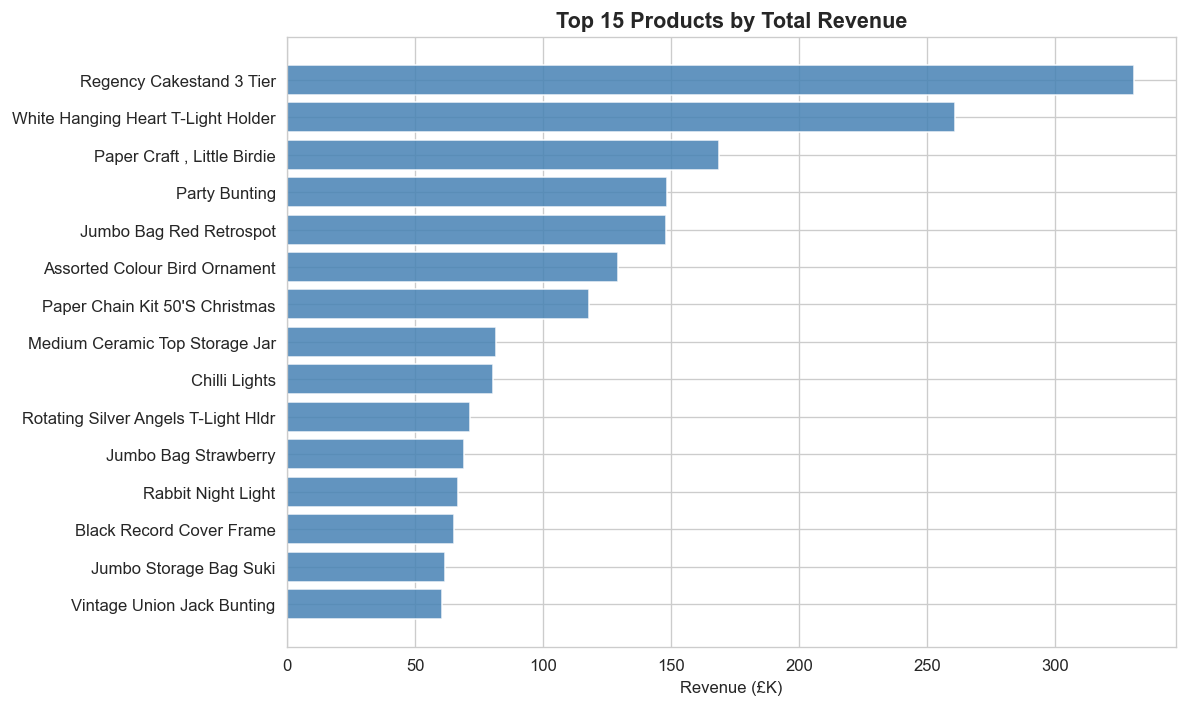

StockCode                         Description  TotalRevenue
    22423            Regency Cakestand 3 Tier     330590.32
   85123A  White Hanging Heart T-Light Holder     260990.22
    23843         Paper Craft , Little Birdie     168469.60
    47566                       Party Bunting     148318.28
   85099B             Jumbo Bag Red Retrospot     148073.47
    84879       Assorted Colour Bird Ornament     129324.49
    22086      Paper Chain Kit 50'S Christmas     117760.29
    23166      Medium Ceramic Top Storage Jar      81700.92
    79321                       Chilli Lights      80540.88
    84347 Rotating Silver Angels T-Light Hldr      71300.40
   85099F                Jumbo Bag Strawberry      69002.13
    23084                  Rabbit Night Light      66870.03
    21137            Black Record Cover Frame      65189.29
    21931              Jumbo Storage Bag Suki      61537.55
    21621          Vintage Union Jack Bunting      60286.04


In [10]:
top_products = (
    df.groupby(['StockCode', 'Description'])['TotalRevenue']
    .sum()
    .reset_index()
    .nlargest(15, 'TotalRevenue')
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_products['Description'].str[:40], top_products['TotalRevenue'] / 1e3,
        color='steelblue', alpha=0.85)
ax.set_xlabel('Revenue (£K)')
ax.set_title('Top 15 Products by Total Revenue', fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/top_products.png', bbox_inches='tight')
plt.show()

print(top_products[['StockCode', 'Description', 'TotalRevenue']].to_string(index=False))

## 7. Revenue by country (ex UK)

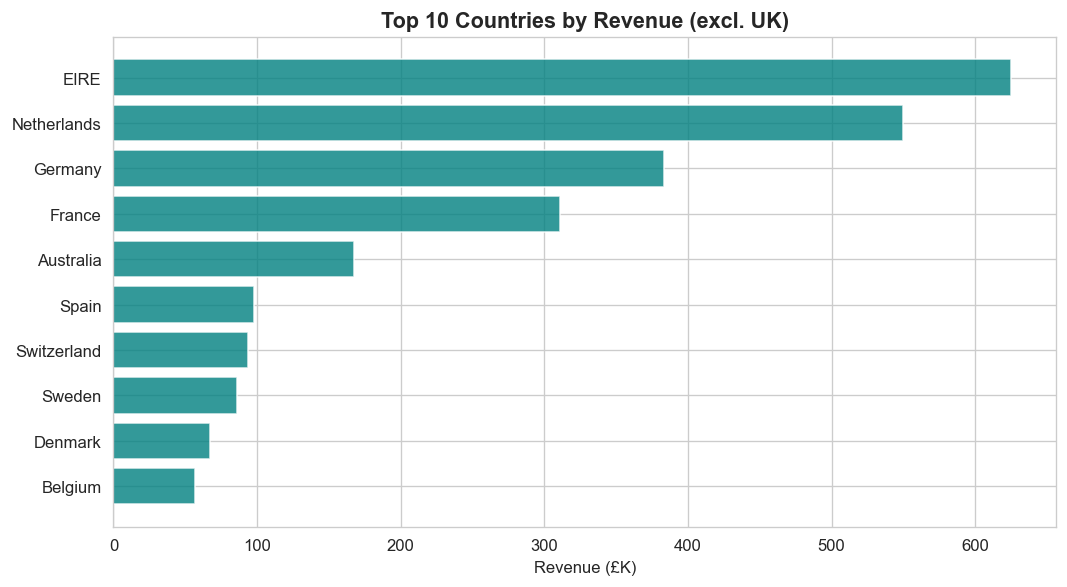

In [11]:
country_rev = (
    df[df['Country'] != 'United Kingdom']
    .groupby('Country')['TotalRevenue']
    .sum()
    .nlargest(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(country_rev['Country'], country_rev['TotalRevenue'] / 1e3, color='teal', alpha=0.8)
ax.set_xlabel('Revenue (£K)')
ax.set_title('Top 10 Countries by Revenue (excl. UK)', fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/revenue_by_country.png', bbox_inches='tight')
plt.show()

## 8. Monthly quantities & invoice count

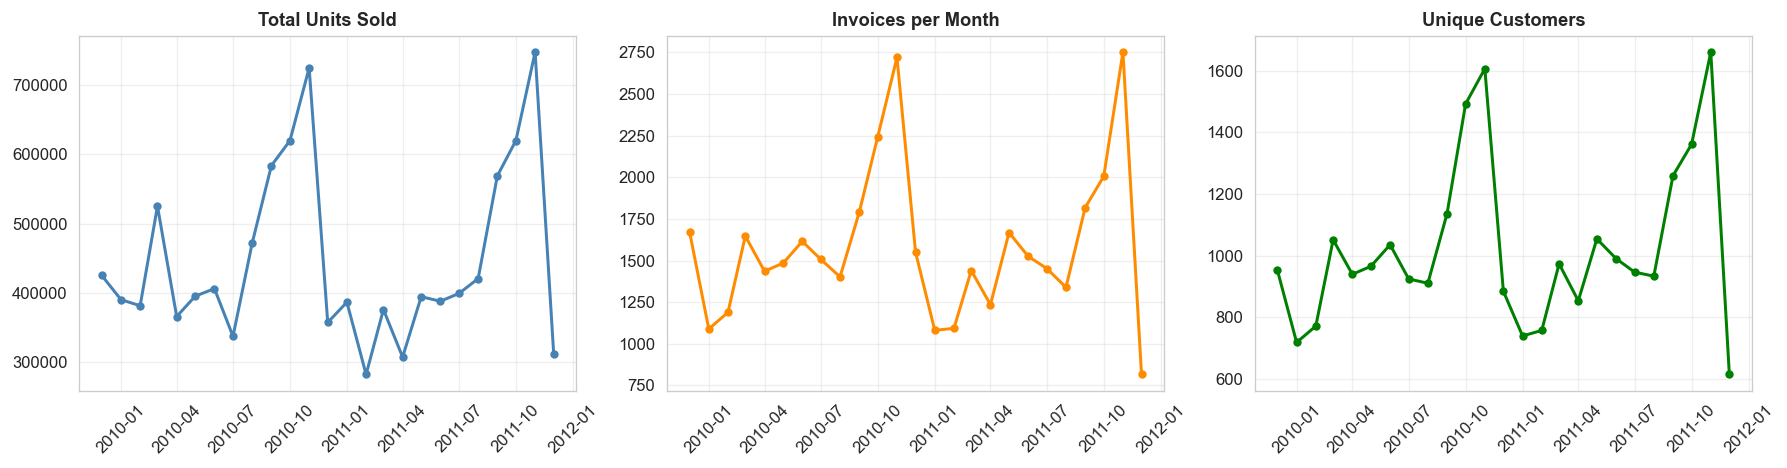

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = [
    ('TotalQuantity', 'Total Units Sold', 'steelblue'),
    ('NumInvoices',   'Invoices per Month', 'darkorange'),
    ('NumCustomers',  'Unique Customers',   'green'),
]

for ax, (col, title, color) in zip(axes, metrics):
    ax.plot(monthly['InvoiceDate'], monthly[col], color=color, marker='o', markersize=4, linewidth=1.8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/monthly_kpis.png', bbox_inches='tight')
plt.show()

## 9. Revenue distribution (box plot by month)

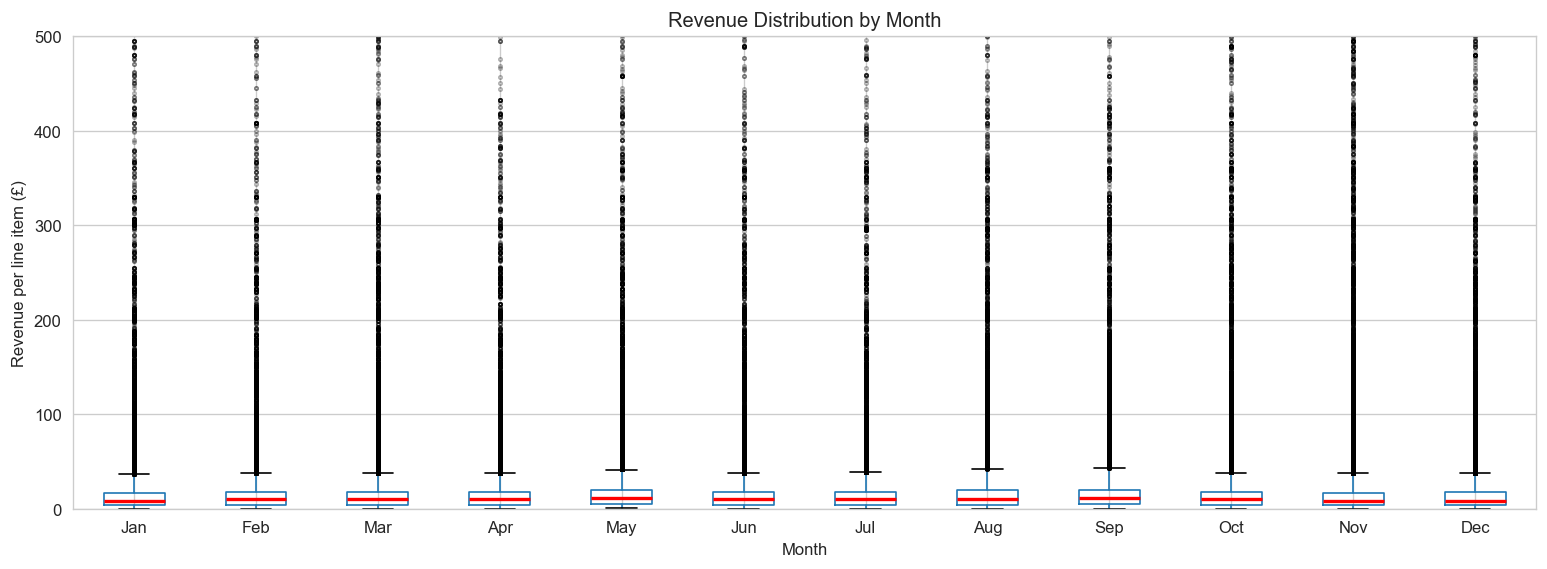

In [13]:
fig, ax = plt.subplots(figsize=(13, 5))
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
df.boxplot(column='TotalRevenue', by='Month', ax=ax,
           flierprops=dict(marker='o', markersize=2, alpha=0.3),
           medianprops=dict(color='red', linewidth=2))
ax.set_xticklabels(month_labels)
ax.set_title('Revenue Distribution by Month')
ax.set_ylabel('Revenue per line item (£)')
fig.suptitle('')
ax.set_ylim(0, 500)  # cap for readability
plt.tight_layout()
plt.savefig('../reports/revenue_boxplot_by_month.png', bbox_inches='tight')
plt.show()

## 10. Key EDA summary

In [15]:
print('=== EDA KEY FINDINGS ===')
print()
print(f'Total Revenue  : £{df["TotalRevenue"].sum():>12,.2f}')
print(f'Avg Monthly Rev: £{monthly["TotalRevenue"].mean():>12,.2f}')
print(f'Peak Month     :  {monthly.loc[monthly["TotalRevenue"].idxmax(), "YearMonth"]}')
print(f'Lowest Month   :  {monthly.loc[monthly["TotalRevenue"].idxmin(), "YearMonth"]}')
print()
print(f'Unique Products : {df["StockCode"].nunique():,}')
print(f'Unique Customers: {df["CustomerID"].nunique():,}')
print(f'Countries       : {df["Country"].nunique()}')
print()
print('→ Strong Q4 seasonality (Oct-Nov peak)')
print('→ UK dominates (~92% of transactions)')
print('→ Tuesday-Thursday are highest revenue days')
print('→ Peak hours: 10:00-14:00')
print()

=== EDA KEY FINDINGS ===

Total Revenue  : £19,655,472.77
Avg Monthly Rev: £  786,218.91
Peak Month     :  2011-11
Lowest Month   :  2011-02

Unique Products : 4,735
Unique Customers: 5,861
Countries       : 43

→ Strong Q4 seasonality (Oct-Nov peak)
→ UK dominates (~92% of transactions)
→ Tuesday-Thursday are highest revenue days
→ Peak hours: 10:00-14:00

